> **Python 3.12 / Anaconda compatibility note**  
> If you see `ImportError: cannot import name 'runtime_version' from 'google.protobuf'`, your installed TensorFlow version uses an older protobuf API that was removed in protobuf 4.x.  
> **Fix** — run this once in a terminal with your virtual environment active:  
> ```
> pip install --upgrade keras tensorflow
> ```  
> This notebook uses **standalone Keras 3** (`import keras`) instead of `from tensorflow import keras`, which avoids the protobuf conflict entirely.

# Lab 0 — Introduction to Keras & TensorFlow

This notebook introduces three foundational deep learning concepts through a minimal, working example:

| Concept | One-line definition |
|---------|--------------------|
| **Epoch** | One complete pass through the training dataset |
| **Loss** | A number measuring how wrong the model's predictions are |
| **Validation** | Evaluating the model on held-out data it has never trained on |

We will train a small neural network to classify handwritten digits (0–9) from the MNIST dataset.  
The entire model fits in fewer than 20 lines of code.

## Step 1 — Import Libraries

- **`keras`** (standalone) — build and train the neural network; avoids the `protobuf` version conflict that occurs with `from tensorflow import keras` on Python 3.12 + Anaconda
- **`numpy`** — numerical operations on arrays
- **`matplotlib`** — plot loss and accuracy curves

> TensorFlow remains the computation backend — we just import Keras independently.

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # suppress TensorFlow C++ warnings

# Standalone Keras 3 — works on Python 3.12 + Anaconda without protobuf conflicts
import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt

print('Keras version     :', keras.__version__)

# TensorFlow is used as the Keras backend; import it for extra info if available
try:
    import tensorflow as tf
    print('TensorFlow version:', tf.__version__)
except Exception as e:
    print('TensorFlow backend info unavailable:', e)

Keras version     : 3.14.0
TensorFlow version: 2.20.0


## Step 2 — Load the MNIST Dataset

Keras downloads MNIST automatically the first time you call `load_data()`.

The dataset arrives pre-split:
- `X_train` / `y_train` — 60,000 images used for **training**
- `X_test`  / `y_test`  — 10,000 images used for **validation** (never seen during training)

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print('Training images :', X_train.shape)   # (60000, 28, 28)
print('Training labels :', y_train.shape)   # (60000,)
print('Test images     :', X_test.shape)    # (10000, 28, 28)
print('Test labels     :', y_test.shape)    # (10000,)
print('Label examples  :', y_train[:10])    # e.g. [5 0 4 1 9 2 1 3 1 4]

Training images : (60000, 28, 28)
Training labels : (60000,)
Test images     : (10000, 28, 28)
Test labels     : (10000,)
Label examples  : [5 0 4 1 9 2 1 3 1 4]


### Peek at the data

Each image is a 28×28 grid of pixel values (0 = black, 255 = white).

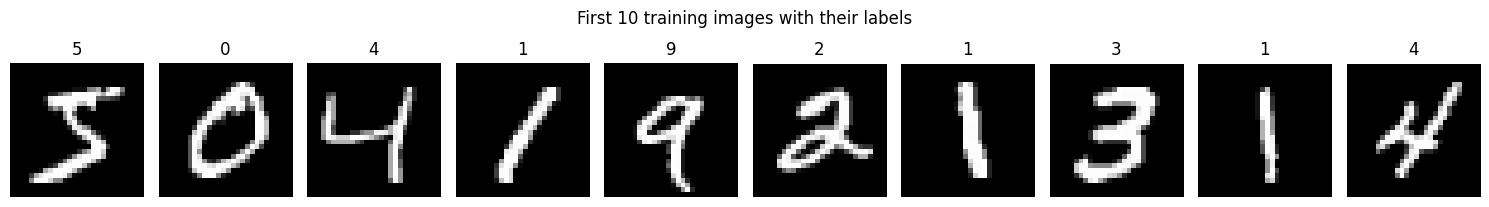

In [4]:
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(str(y_train[i]), fontsize=12)
    ax.axis('off')
plt.suptitle('First 10 training images with their labels', y=1.02)
plt.tight_layout()
plt.show()

## Step 3 — Preprocess the Data

Two transformations are needed before training:

1. **Flatten** — reshape each 28×28 image into a flat vector of 784 numbers.  
   Dense (fully-connected) layers require a 1-D input.

2. **Normalise** — divide every pixel value by 255 to scale the range from [0, 255] to [0.0, 1.0].  
   Smaller numbers make gradient descent faster and more stable.

In [5]:
# Flatten 28x28 -> 784 and normalise to [0, 1]
X_train = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test  = X_test.reshape(-1, 784).astype('float32') / 255.0

# One-hot encode labels: digit 3 becomes [0,0,0,1,0,0,0,0,0,0]
y_train_cat = keras.utils.to_categorical(y_train, num_classes=10)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes=10)

print('X_train shape after reshape:', X_train.shape)    # (60000, 784)
print('y_train shape after one-hot:', y_train_cat.shape)  # (60000, 10)
print('Example label (digit 5)    :', y_train_cat[0])   # [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

X_train shape after reshape: (60000, 784)
y_train shape after one-hot: (60000, 10)
Example label (digit 5)    : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## Step 4 — Build the Model

We use a **Sequential** model — layers are stacked one after another:

```
Input  →  Dense(128, ReLU)  →  Dense(10, Softmax)  →  Output
784 neurons     128 neurons          10 neurons
```

- **Dense layer** — every input neuron connects to every output neuron.
- **ReLU** — activation function: `f(x) = max(0, x)`. Adds non-linearity.
- **Softmax** — converts 10 raw scores into probabilities that sum to 1.0.

In [6]:
model = keras.Sequential([
    keras.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10,  activation='softmax'),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## Step 5 — Compile the Model

Compiling attaches three things to the model:

| Argument | Value | Purpose |
|----------|-------|---------|
| `optimizer` | `'adam'` | Algorithm that updates the weights to reduce loss |
| `loss` | `'categorical_crossentropy'` | Measures how wrong the predictions are |
| `metrics` | `['accuracy']` | Human-readable score printed after each epoch |

In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Step 6 — Train the Model

`model.fit()` runs the training loop.

Key arguments:
- `epochs=10` — repeat the full training pass 10 times
- `batch_size=128` — process 128 images per gradient update
- `validation_data=(X_test, y_test_cat)` — after each epoch, evaluate on the test set

Watch the output: `loss` and `val_loss` should both decrease each epoch.

In [8]:
history = model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 951us/step - accuracy: 0.8997 - loss: 0.3619 - val_accuracy: 0.9434 - val_loss: 0.2003
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - accuracy: 0.9519 - loss: 0.1713 - val_accuracy: 0.9604 - val_loss: 0.1443
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - accuracy: 0.9651 - loss: 0.1226 - val_accuracy: 0.9665 - val_loss: 0.1138
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - accuracy: 0.9729 - loss: 0.0943 - val_accuracy: 0.9705 - val_loss: 0.1019
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - accuracy: 0.9781 - loss: 0.0774 - val_accuracy: 0.9733 - val_loss: 0.0905
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step - accuracy: 0.9824 - loss: 0.0637 - val_accuracy: 0.9735 - val_loss: 0.0886
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step - accuracy: 0.9843 - loss: 0.0541 - val_accuracy: 0.9761 - val_loss: 0.0808
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - accuracy: 0.9869 - loss: 0.0455 - 

## Step 7 — Evaluate on the Test Set

This gives the final, honest accuracy on data the model was never trained on.

In [9]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f'Test loss    : {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy * 100:.2f}%')

Test loss    : 0.0805
Test accuracy: 97.66%


## Step 8 — Plot Loss & Accuracy Curves

The `history` object returned by `model.fit()` records the loss and accuracy after every epoch.  
Plotting these curves is the standard way to diagnose training:

- **Good result** — training and validation curves track each other closely
- **Overfitting** — training loss keeps falling while validation loss levels off or rises

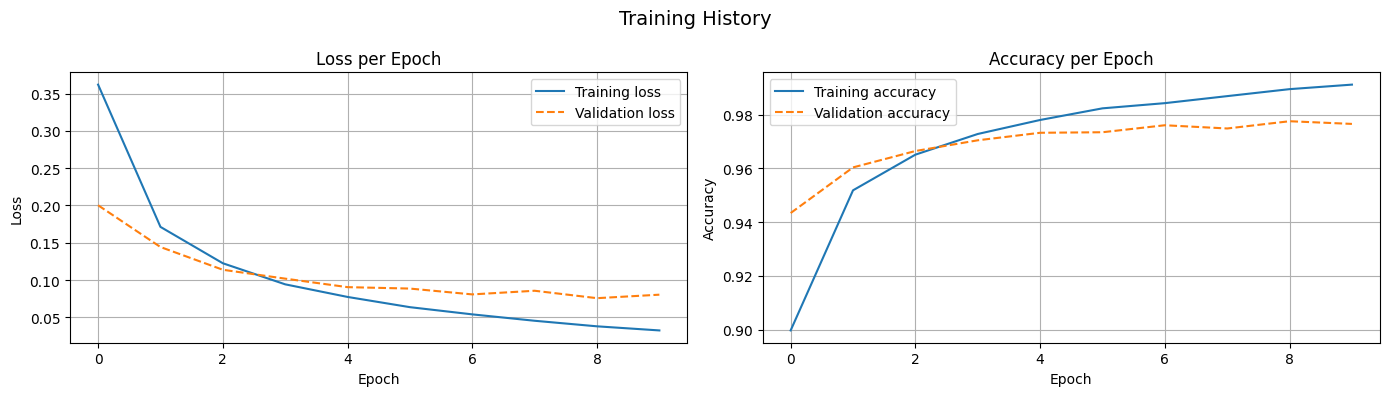

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Loss ---
axes[0].plot(history.history['loss'],     label='Training loss')
axes[0].plot(history.history['val_loss'], label='Validation loss', linestyle='--')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# --- Accuracy ---
axes[1].plot(history.history['accuracy'],     label='Training accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation accuracy', linestyle='--')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Training History', fontsize=14)
plt.tight_layout()
plt.show()

## Step 9 — Make Predictions

`model.predict()` returns a probability array of shape `(n_samples, 10)`.  
`np.argmax()` picks the index with the highest probability — that is the predicted digit.

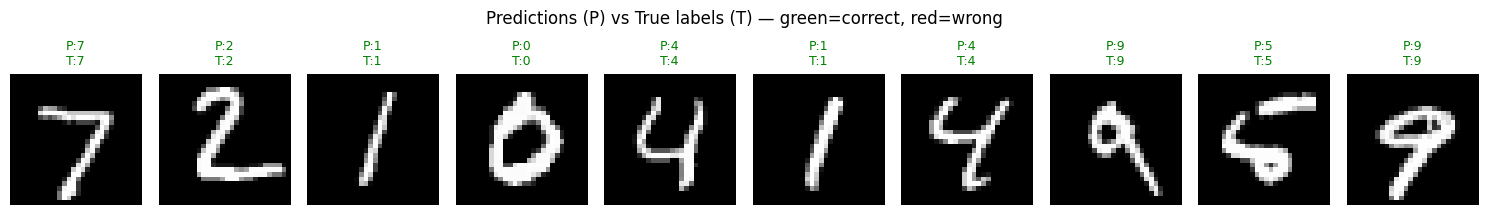

In [11]:
predictions = model.predict(X_test[:10], verbose=0)
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = y_test[:10]

# Show the first 10 test images with predicted and true labels
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    color = 'green' if predicted_labels[i] == true_labels[i] else 'red'
    ax.set_title(f'P:{predicted_labels[i]}\nT:{true_labels[i]}', color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('Predictions (P) vs True labels (T) — green=correct, red=wrong', y=1.05)
plt.tight_layout()
plt.show()

## Step 10 — Confusion Matrix

A **confusion matrix** shows how often the model confuses one digit for another.  
Rows represent the **true** digit; columns represent the **predicted** digit.  
Correct predictions sit on the diagonal; off-diagonal cells are mistakes.

### TP / FP / FN / TN — for a single class (e.g. digit "7")

| Term | Meaning | Example |
|------|---------|---------|
| **True Positive (TP)** | Model predicted 7 **and** it really was 7 | Correct 7 ✓ |
| **False Positive (FP)** | Model predicted 7 **but** it was a different digit | Called a 1 a 7 ✗ |
| **False Negative (FN)** | It really was 7 **but** model predicted something else | Missed a real 7 ✗ |
| **True Negative (TN)** | Model did **not** predict 7 **and** it wasn't 7 | Correctly ignored ✓ |

> In a 10-class problem these counts exist separately for each digit class.

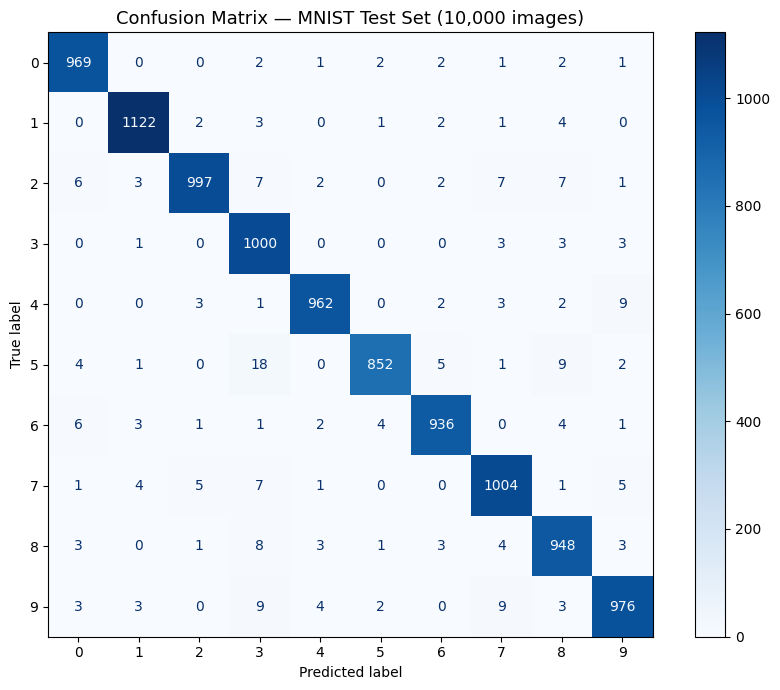


Top 5 most-confused pairs (true → predicted):
  true=5  predicted=3  errors=18
  true=4  predicted=9  errors=9
  true=5  predicted=8  errors=9
  true=9  predicted=3  errors=9
  true=9  predicted=7  errors=9


In [12]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Predict on the full test set
y_pred_all = np.argmax(model.predict(X_test, verbose=0), axis=1)

cm = confusion_matrix(y_test, y_pred_all)
fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — MNIST Test Set (10,000 images)', fontsize=13)
plt.tight_layout()
plt.show()

# Print the worst-confused pairs
print('\nTop 5 most-confused pairs (true → predicted):')
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)          # zero out the diagonal to find off-diagonal mistakes
for _ in range(5):
    idx = np.unravel_index(cm_copy.argmax(), cm_copy.shape)
    print(f'  true={idx[0]}  predicted={idx[1]}  errors={cm_copy[idx]}')
    cm_copy[idx] = 0

## Step 11 — Precision, Recall & F1 Score

Accuracy alone can be misleading (e.g. if 90 % of samples belong to one class).  
Three complementary metrics give a fuller picture, **per class**:

$$\text{Precision} = \frac{TP}{TP + FP}$$

> Of every time we predicted "7", how often were we right?

$$\text{Recall} = \frac{TP}{TP + FN}$$

> Of every real "7" in the dataset, how many did we find?

$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

> Harmonic mean of Precision and Recall — penalises extreme imbalance between the two.

A model with **high precision but low recall** is conservative — it only calls "7" when it is very sure, missing many real 7s.  
A model with **high recall but low precision** is aggressive — it calls almost everything "7", catching all real 7s but producing many false alarms.

In [13]:
from sklearn.metrics import classification_report

# Predict on the full test set
y_pred_all = np.argmax(model.predict(X_test, verbose=0), axis=1)

report = classification_report(
    y_test, y_pred_all,
    target_names=[f'digit {i}' for i in range(10)]
)
print(report)

              precision    recall  f1-score   support

     digit 0       0.98      0.99      0.98       980
     digit 1       0.99      0.99      0.99      1135
     digit 2       0.99      0.97      0.98      1032
     digit 3       0.95      0.99      0.97      1010
     digit 4       0.99      0.98      0.98       982
     digit 5       0.99      0.96      0.97       892
     digit 6       0.98      0.98      0.98       958
     digit 7       0.97      0.98      0.97      1028
     digit 8       0.96      0.97      0.97       974
     digit 9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



## Summary

| Concept | What you observed in this notebook |
|---------|------------------------------------|
| **Epoch** | Training ran for 10 epochs. Each line of `model.fit()` output = 1 epoch |
| **Loss** | Started near `2.3` (random guessing), fell to `~0.07` by epoch 10 |
| **Validation** | `val_loss` and `val_accuracy` measured on 10k test images after each epoch |
| **Confusion Matrix** | Grid showing which digits the model confuses with each other; ideal result = bold diagonal |
| **Precision** | Of all predicted "X"s, what fraction were actually "X"? |
| **Recall** | Of all real "X"s in the data, what fraction did the model find? |
| **F1 Score** | Harmonic mean of Precision and Recall — single balanced metric per class |

### Try it yourself

1. Change `epochs=10` to `epochs=30` — does validation accuracy keep improving?
2. Change `Dense(128, ...)` to `Dense(32, ...)` — does the model still learn?
3. Add a second hidden layer (`layers.Dense(64, activation='relu')`) — does accuracy improve?
4. Look at the confusion matrix — which two digits does the model most often mix up? Why might that be?

When you are comfortable with these concepts, move on to **Lab 1** for a full MNIST walkthrough.